<a href="https://colab.research.google.com/github/Veerababu77/Simple-RAG-Architecture/blob/main/Simple_RAG_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **RAG - Retrival Augmented Generation**

# Installing Required packages

In [1]:
!pip install openai chromadb python-dotenv
!pip install -U google-genai
!pip install -U langchain-text-splitters

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.4 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-api
    Found ex

# Import required packages

In [2]:
import os
import json
from openai import OpenAI
from dotenv import load_dotenv
import chromadb


# Import Google Gemini API Key to use LLM

In [7]:
from google.colab import userdata
from google import genai

geminikey = userdata.get('Gemini_API_Key')
print(geminikey is not None, len(geminikey) if geminikey else 0)
client = genai.Client( api_key = geminikey)

True 53


# Communication to the Gemini

In [8]:
from google.genai import types

response = client.models.generate_content(
    model = 'gemini-3.6-flash',
    contents="What is RAG? Explain in simple English",
    config=types.GenerateContentConfig(
        system_instruction="You are a helpful assistant."
    )
)
print(response.text)

**RAG** stands for **Retrieval-Augmented Generation**. 

In simple English, it is a way to give an AI chatbot an **"open-book test"** so it gives more accurate, up-to-date, and truthful answers.

---

### The Analogy: Closed-Book vs. Open-Book

To understand RAG, imagine taking a history exam:

* **Standard AI (Closed-Book Test):** The AI relies *only* on its memory (what it learned during training). If you ask it a question about something obscure or recent, it might guess, get confused, or completely make up a fake answer (this is called "hallucination").
* **RAG-powered AI (Open-Book Test):** When you ask a question, the AI first goes to a library, finds the exact book or page with the right information, reads it, and *then* writes down the answer for you. 

---

### How RAG Works in 3 Steps

The name tells you exactly how it works:

1. **Retrieval (Search):** When you ask a question, the system searches a specific database or set of documents (like company files, manuals, or news a

# Load the input documents

In [10]:
with open("/content/acme_rag_combined_dataset.txt", "r") as f:
  acme_technologies = f.read()

In [11]:
print(f'Length of the acme technologies document: {len(acme_technologies)}')

Length of the acme technologies document: 10192


# **Chunking the document using Langchain text splitter**

In [13]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size = 100, chunk_overlap = 0)
acme_chunked = text_splitter.split_text(acme_technologies)

In [14]:
print(f'Length of the chunks:  {len(acme_chunked)} ')

Length of the chunks:  146 


# Initialization ChromaDB to store embeddings

In [15]:
chroma_client = chromadb.Client()
collection = chroma_client.create_collection(name = 'acme_technologies')

In [16]:
documents = []
ids = []
metadata = []

for i, chunk in enumerate(acme_chunked):
  documents.append(chunk)
  ids.append(f'chunk_{i}')
  metadata.append({"source": "acme technologies"})

print(documents[0])
print(ids[0])
print(metadata[0])


ACME TECHNOLOGIES — RAG TEST DATASET
chunk_0
{'source': 'acme technologies'}


In [17]:
collection.add(
    documents = documents,
    ids = ids,
    metadatas = metadata
)

/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:06<00:00, 12.8MiB/s]


# Function to retrive n chunks related to question using cosine similarity

In [18]:
def retrive(question, n_results = 3):
  results = collection.query(
      query_texts = [question],
      n_results = n_results
  )
  return results['documents'][0], results['metadatas'][0]

In [19]:
chunks, sources = retrive("what is acme technologies", 4)

In [20]:
for chunk in chunks:
  print(chunk)

Acme Technologies is a fictional software company founded in 2018. The company develops cloud-based
9. PRODUCTS
-----------

Acme Technologies Products
AcmeAI is the company's artificial intelligence platform.
7. ENGINEERING TEAM
-------------------

Acme Technologies Engineering Team


# Function to communicate to the Gemini

In [21]:
from google.genai import types

def ask_rag(question, n_results= 10, verbose=True):
    chunks, sources = retrive(question, n_results)
    context = ' '.join(chunks)

    response = client.models.generate_content(
        model='gemini-3.6-flash',
        contents=f"Context: {context}\n\n-----\n\nQuestion: {question}",
        config=types.GenerateContentConfig(
            system_instruction=(
                "You are a helpful assistant that answers the question based on given context. "
                "If the context does not contain the answer, say 'I don't have enough information'. "
                "Don't make up information or assume anything."
            )
        )
    )

    answer = response.text
    if verbose:
        print(answer)
    return answer

In [24]:
answer = ask_rag("What is Acme Technologies?")

Based on the provided context, Acme Technologies is a fictional software company founded in 2018.


In [25]:
answer = ask_rag("Can an employee work remotely two days a week?")

Yes, under the standard hybrid arrangement, an employee can work remotely up to two days per week.


In [27]:
answer = ask_rag("A backend engineer wants to build an asynchronous API processing system. Which technologies in the company are relevant?")

Based on the provided context, the following technologies in the company are relevant for building an asynchronous API processing system:

* **Django** and **Django REST Framework**: Commonly used to build APIs.
* **Celery**: Used for asynchronous background jobs.
* **Redis**: Used for background task coordination and caching.
* **Python**: The primary programming language for backend services.
* **PostgreSQL**, **Docker**, and **AWS**: Used by the engineering department for backend services.


In [28]:
ask_rag("An employee wants to buy an online Python course for INR 15,000. Can they use the company's learning allowance and what is the reimbursement deadline?", 10)

Yes, the employee can use the company's learning allowance. The company provides an annual learning allowance of INR 20,000 per employee for approved technical courses, which covers the INR 15,000 cost. 

The reimbursement deadline requires employees to submit reimbursement requests within 30 days of completing a purchase.


"Yes, the employee can use the company's learning allowance. The company provides an annual learning allowance of INR 20,000 per employee for approved technical courses, which covers the INR 15,000 cost. \n\nThe reimbursement deadline requires employees to submit reimbursement requests within 30 days of completing a purchase."

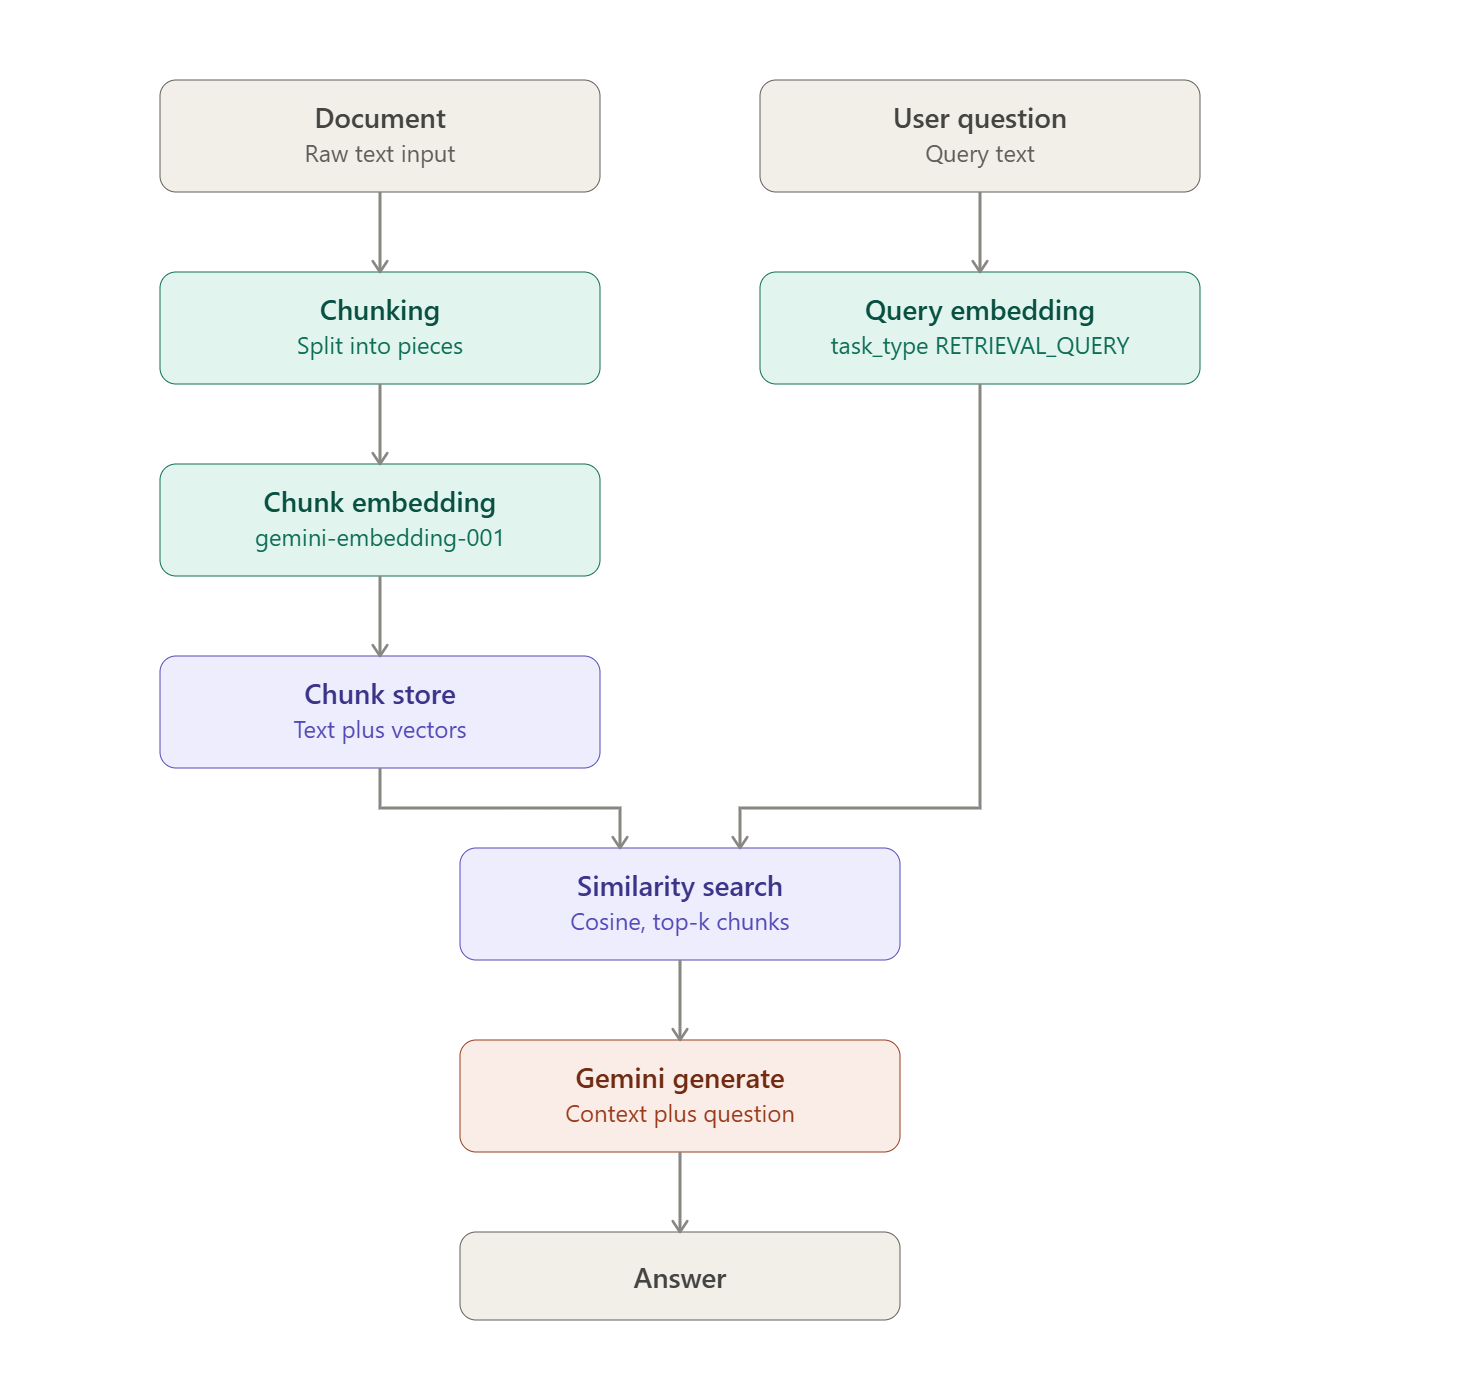